In [ ]:
!nvidia-smi

Tue Mar 24 07:14:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install roboflow torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="RI1JpVN3PSyL0DqEzCWx")
project = rf.workspace("dhairyas-workspace-0eca3").project("cityscapes-wqjba-vmdeh")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Cityscapes-1 in yolov8:: 100%|██████████| 16616/16616 [00:02<00:00, 7369.92it/s]


In [ ]:
import torch
import torch.nn as nn

# ---------------------------------------------------------
# Custom Hardware Block: Depthwise Separable Convolution
# ---------------------------------------------------------
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(DepthwiseSeparableConv, self).__init__()

        # Step 1: Depthwise (Spatial filtering)
        # Groups = in_channels means it processes each channel independently
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   stride=stride, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)

        # Step 2: Pointwise (Channel mixing)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                                   stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Standard ReLU translates easily to hardware (just check if bit > 0)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.depthwise(x)))
        x = self.relu(self.bn2(self.pointwise(x)))
        return x

# ---------------------------------------------------------
# Main Model: Custom YOLO NPU Target
# ---------------------------------------------------------
class HardwareFriendlyYOLO(nn.Module):
    def __init__(self, num_classes=2):
        super(HardwareFriendlyYOLO, self).__init__()

        # Backbone: Aggressive downsampling to save memory buffers
        # Assuming our Roboflow input is exactly 320x320 RGB
        self.backbone = nn.Sequential(
            # Standard initial conv to extract base edges
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False), # Output: 160x160
            nn.BatchNorm2d(16),
            nn.ReLU(),

            # Switch to efficient blocks
            DepthwiseSeparableConv(16, 32, stride=2),  # Output: 80x80
            DepthwiseSeparableConv(32, 64, stride=2),  # Output: 40x40
            DepthwiseSeparableConv(64, 128, stride=2), # Output: 20x20
            DepthwiseSeparableConv(128, 256, stride=2) # Output: 10x10
        )

        # Head: The Bounding Box Predictor
        # We output a 10x10 grid.
        # Channels = 4 (x,y,w,h) + 1 (Objectness score) + 2 (Car, Person) = 7
        self.head = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 7, kernel_size=1, stride=1, padding=0)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        return out

# ---------------------------------------------------------
# Hardware Tensor Verification Check
# ---------------------------------------------------------
if __name__ == "__main__":
    # Create a dummy image tensor (Batch=1, Channels=3, 320x320)
    dummy_input = torch.randn(1, 3, 320, 320)

    # Initialize our custom architecture
    model = HardwareFriendlyYOLO(num_classes=2)

    # Pass data through
    output = model(dummy_input)

    print("=== NPU Architecture Initialized ===")
    print(f"Input Image Shape:  {dummy_input.shape}")
    print(f"Output Tensor Shape: {output.shape}")

=== NPU Architecture Initialized ===
Input Image Shape:  torch.Size([1, 3, 320, 320])
Output Tensor Shape: torch.Size([1, 7, 10, 10])


In [ ]:
import os
import torch
import cv2
from torch.utils.data import Dataset, DataLoader
import numpy as np

class RoboflowYOLODataset(Dataset):
    def __init__(self, image_dir, label_dir, grid_size=10, num_classes=2):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.grid_size = grid_size
        self.num_classes = num_classes

        # Get all image files
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1. Load Image
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Normalize image pixels to [0, 1] for hardware-friendly math
        image = image / 255.0
        # Convert to PyTorch Tensor: [Channels, Height, Width]
        image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # 2. Load Labels
        label_name = img_name.replace('.jpg', '.txt')
        label_path = os.path.join(self.label_dir, label_name)

        # Create an empty target tensor: [7 channels, 10x10 grid]
        # Channels: [x, y, w, h, objectness, class0, class1]
        target = torch.zeros((4 + 1 + self.num_classes, self.grid_size, self.grid_size))

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x, y, w, h = map(float, line.strip().split())
                    class_id = int(class_id)

                    # Determine which grid cell (i, j) the center of the bounding box falls into
                    grid_i = int(y * self.grid_size)
                    grid_j = int(x * self.grid_size)

                    # Check if the cell is already occupied (YOLO only predicts one object per cell)
                    if target[4, grid_i, grid_j] == 0:
                        # Set coordinates
                        target[0, grid_i, grid_j] = x
                        target[1, grid_i, grid_j] = y
                        target[2, grid_i, grid_j] = w
                        target[3, grid_i, grid_j] = h

                        # Set objectness score to 1 (There is an object here)
                        target[4, grid_i, grid_j] = 1.0

                        # One-hot encode the class
                        target[5 + class_id, grid_i, grid_j] = 1.0

        return image_tensor, target

# ---------------------------------------------------------
# Verification Check: Load a Batch
# ---------------------------------------------------------
if __name__ == "__main__":
    # NOTE: Replace these paths with the actual paths from your dataset.location
    # Example: image_dir = f"{dataset.location}/train/images"
    # Make sure to run the Roboflow download cell first!

    try:
        train_img_dir = f"{dataset.location}/train/images"
        train_lbl_dir = f"{dataset.location}/train/labels"

        custom_dataset = RoboflowYOLODataset(train_img_dir, train_lbl_dir)

        # Create a DataLoader to batch the images together
        train_loader = DataLoader(custom_dataset, batch_size=4, shuffle=True)

        # Grab one batch
        images, targets = next(iter(train_loader))

        print("=== Data Pipeline Verified ===")
        print(f"Batch Image Shape:  {images.shape}")   # Expected: [4, 3, 320, 320]
        print(f"Batch Target Shape: {targets.shape}")  # Expected: [4, 7, 10, 10]
        print(f"Successfully loaded a batch of {images.shape[0]} images!")

    except NameError:
        print("Error: 'dataset' variable not found. Make sure you ran the Roboflow download cell!")

=== Data Pipeline Verified ===
Batch Image Shape:  torch.Size([4, 3, 320, 320])
Batch Target Shape: torch.Size([4, 7, 10, 10])
Successfully loaded a batch of 4 images!


In [ ]:
import torch
import torch.nn as nn

class HardwareYOLOLoss(nn.Module):
    def __init__(self, lambda_coord=5.0, lambda_noobj=0.5):
        super(HardwareYOLOLoss, self).__init__()
        # We use MSE for everything to keep operations simple.
        # 'reduction=sum' adds up all the errors across the grid.
        self.mse = nn.MSELoss(reduction='sum')

        # YOLO specific multipliers.
        # We penalize bad bounding boxes heavily (5.0)
        # We penalize guessing "object" in an empty cell lightly (0.5) so it doesn't get overly conservative.
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, predictions, targets):
        # Predictions & Targets Shape: [Batch, 7 channels, 10, 10]
        # Channels: 0:x, 1:y, 2:w, 3:h, 4:objectness, 5:class_car, 6:class_person

        # 1. Create Masks
        # We only want to calculate box and class errors if an object actually exists in that cell.
        # Mask shape will be [Batch, 10, 10] with True/False values
        obj_mask = targets[:, 4, :, :] == 1    # Cells with objects
        noobj_mask = targets[:, 4, :, :] == 0  # Empty background cells

        # 2. Bounding Box Coordinate Loss (Only for cells WITH objects)
        # Extract x, y, w, h channels and apply the mask
        pred_boxes = predictions[:, 0:4, :, :].permute(0, 2, 3, 1)[obj_mask]
        target_boxes = targets[:, 0:4, :, :].permute(0, 2, 3, 1)[obj_mask]
        box_loss = self.mse(pred_boxes, target_boxes)

        # 3. Objectness Confidence Loss
        # Calculate error for cells WITH objects (should be 1)
        pred_conf_obj = predictions[:, 4, :, :][obj_mask]
        target_conf_obj = targets[:, 4, :, :][obj_mask]
        obj_loss = self.mse(pred_conf_obj, target_conf_obj)

        # Calculate error for empty background cells (should be 0)
        pred_conf_noobj = predictions[:, 4, :, :][noobj_mask]
        target_conf_noobj = targets[:, 4, :, :][noobj_mask]
        noobj_loss = self.mse(pred_conf_noobj, target_conf_noobj)

        # 4. Classification Loss (Only for cells WITH objects)
        pred_classes = predictions[:, 5:7, :, :].permute(0, 2, 3, 1)[obj_mask]
        target_classes = targets[:, 5:7, :, :].permute(0, 2, 3, 1)[obj_mask]
        class_loss = self.mse(pred_classes, target_classes)

        # 5. Final Combined Loss
        total_loss = (
            (self.lambda_coord * box_loss) +
            obj_loss +
            (self.lambda_noobj * noobj_loss) +
            class_loss
        )

        return total_loss

print("Custom YOLO Loss Function Ready!")

Custom YOLO Loss Function Ready!


In [ ]:
import torch.optim.lr_scheduler as lr_scheduler

# Crank up the epochs!
num_epochs = 100

# Re-initialize to wipe the bad memory
model = HardwareFriendlyYOLO(num_classes=2).to(device)
criterion = HardwareYOLOLoss(lambda_coord=5.0, lambda_noobj=1.5) # Punish false positives harder

# Optimizer and our new Scheduler
optimizer = optim.Adam(model.parameters(), lr=0.001)
# This will slowly drop the learning rate down to 0.00001 by the end of training
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

print("=== Starting Deep Training Engine ===")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Step the scheduler down
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    avg_loss = epoch_loss / len(train_loader)

    # Print every 5 epochs to keep the console clean
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")

torch.save(model.state_dict(), "npu_yolo_weights_fp32_deep.pth")
print("Deep Training Complete. Weights saved!")

=== Starting Deep Training Engine ===
Epoch [1/100] | Loss: 180.0557 | LR: 0.001000
Epoch [5/100] | Loss: 96.5265 | LR: 0.000994
Epoch [10/100] | Loss: 69.2762 | LR: 0.000976
Epoch [15/100] | Loss: 52.0629 | LR: 0.000946
Epoch [20/100] | Loss: 41.8083 | LR: 0.000905
Epoch [25/100] | Loss: 34.9681 | LR: 0.000855
Epoch [30/100] | Loss: 29.9814 | LR: 0.000796
Epoch [35/100] | Loss: 26.4929 | LR: 0.000730
Epoch [40/100] | Loss: 23.6602 | LR: 0.000658
Epoch [45/100] | Loss: 21.4282 | LR: 0.000582
Epoch [50/100] | Loss: 19.4703 | LR: 0.000505
Epoch [55/100] | Loss: 17.6780 | LR: 0.000428
Epoch [60/100] | Loss: 16.5556 | LR: 0.000352
Epoch [65/100] | Loss: 15.3907 | LR: 0.000280
Epoch [70/100] | Loss: 14.4887 | LR: 0.000214
Epoch [75/100] | Loss: 13.8200 | LR: 0.000155
Epoch [80/100] | Loss: 13.1132 | LR: 0.000105
Epoch [85/100] | Loss: 12.4889 | LR: 0.000064
Epoch [90/100] | Loss: 12.1560 | LR: 0.000034
Epoch [95/100] | Loss: 11.8608 | LR: 0.000016
Epoch [100/100] | Loss: 11.8383 | LR: 0.000

Testing Model on: strasbourg_000001_059914_leftImg8bit_png.rf.59577d56adb6bc46c0ced94405cc6201.jpg


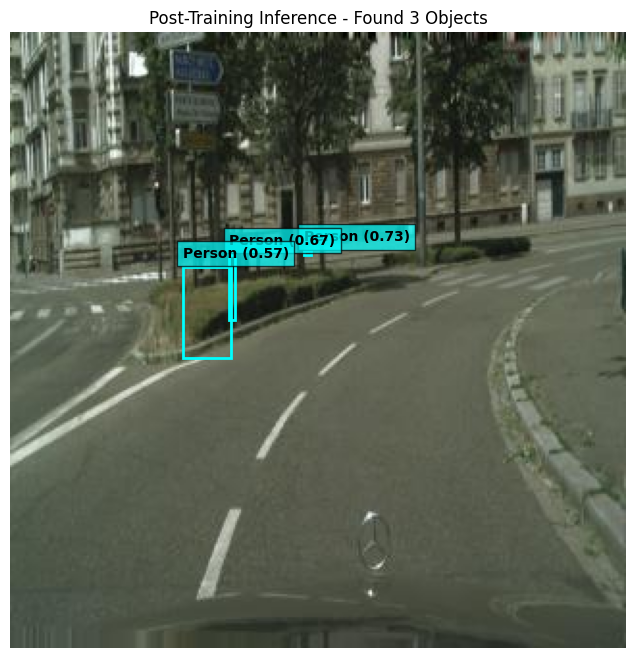

In [46]:
import torch
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import glob
import random

# --- 1. Load the Deep Training Weights ---
model = HardwareFriendlyYOLO(num_classes=2).to(device)
model.load_state_dict(torch.load("npu_yolo_weights_fp32_deep.pth"))
model.eval()

# --- 2. Simple Intersection over Union (IoU) & NMS logic ---
def calculate_iou(box1, box2):
    # Boxes are [x_min, y_min, x_max, y_max]
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

def non_max_suppression(boxes, iou_threshold=0.4):
    # Sort boxes by confidence score (highest first)
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    kept_boxes = []

    while boxes:
        best_box = boxes.pop(0)
        kept_boxes.append(best_box)
        # Keep only boxes that do NOT heavily overlap with the best box
        boxes = [b for b in boxes if calculate_iou(best_box[:4], b[:4]) < iou_threshold]
    return kept_boxes

# --- 3. Grab a random test image ---
test_images = glob.glob(f"{dataset.location}/valid/images/*.jpg")
if len(test_images) == 0:
    test_images = glob.glob(f"{dataset.location}/train/images/*.jpg")

img_path = random.choice(test_images)
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
resized_img = cv2.resize(original_img, (320, 320))
img_normalized = resized_img / 255.0

img_tensor = torch.tensor(img_normalized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

print(f"Testing Model on: {img_path.split('/')[-1]}")

# --- 4. Forward Pass ---
with torch.no_grad():
    predictions = model(img_tensor)
pred_grid = predictions[0].cpu()

# --- 5. Extract and Filter Boxes ---
grid_size = 10
confidence_threshold = 0.5
classes = ["Car", "Person"]
raw_boxes = []

for i in range(grid_size):
    for j in range(grid_size):
        obj_score = pred_grid[4, i, j].item()
        if obj_score > confidence_threshold:
            x_center = pred_grid[0, i, j].item() * 320
            y_center = pred_grid[1, i, j].item() * 320
            width = pred_grid[2, i, j].item() * 320
            height = pred_grid[3, i, j].item() * 320

            x_min = x_center - (width / 2)
            y_min = y_center - (height / 2)
            x_max = x_center + (width / 2)
            y_max = y_center + (height / 2)

            class_probs = pred_grid[5:7, i, j]
            class_id = torch.argmax(class_probs).item()

            # Store [x_min, y_min, x_max, y_max, confidence, class_id]
            raw_boxes.append([x_min, y_min, x_max, y_max, obj_score, class_id])

# Run NMS to clean up the duplicates
final_boxes = non_max_suppression(raw_boxes, iou_threshold=0.4)

# --- 6. Visualization ---
fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(resized_img)

for box in final_boxes:
    x_min, y_min, x_max, y_max, conf, cls_id = box
    w_pixel = x_max - x_min
    h_pixel = y_max - y_min
    class_name = classes[cls_id]

    color = 'red' if class_name == 'Car' else 'cyan'
    rect = patches.Rectangle((x_min, y_min), w_pixel, h_pixel, linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    plt.text(x_min, y_min - 5, f"{class_name} ({conf:.2f})",
             color='black', fontsize=10, fontweight='bold', bbox=dict(facecolor=color, alpha=0.7))

plt.title(f"Post-Training Inference - Found {len(final_boxes)} Objects")
plt.axis('off')
plt.show()